<a href="https://colab.research.google.com/github/vedz-21/Machine_Learning-2/blob/main/ML2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PROGRAM-1**


In [ ]:
#program 1
import torch
import torch.nn as nn
import torch.optim as optim
import re

text = "Natural language processing enables computers to understand human language"
words = re.findall(r'\w+', text.lower())

vocab = {w:i for i,w in enumerate(sorted(set(words)))}

pairs = [(words[i], words[i+1]) for i in range(len(words)-1)]
print("Sample training pairs:", pairs)

train = [(vocab[a], vocab[b]) for a,b in pairs]

class Word2Vec(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(len(vocab), 10)
        self.fc = nn.Linear(10, len(vocab))
    def forward(self, x):
        return self.fc(self.embed(x))

model = Word2Vec()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(50):
    loss = 0
    for x, y in train:
        x = torch.tensor([x])
        y = torch.tensor([y])

        optimizer.zero_grad()
        output = model(x)
        l = loss_fn(output, y)
        l.backward()
        optimizer.step()
        loss += l.item()
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss:.4f}")
embeddings = model.embed.weight.detach()
print("\nWord Embedding for 'language':")
print(embeddings[vocab["language"]])
print("\nWord Embedding for 'natural':")
print(embeddings[vocab["natural"]])

Sample training pairs: [('natural', 'language'), ('language', 'processing'), ('processing', 'enables'), ('enables', 'computers'), ('computers', 'to'), ('to', 'understand'), ('understand', 'human'), ('human', 'language')]
Epoch 10, Loss: 4.4402
Epoch 20, Loss: 0.8880
Epoch 30, Loss: 0.3337
Epoch 40, Loss: 0.1766
Epoch 50, Loss: 0.1103

Word Embedding for 'language':
tensor([ 1.0820,  0.0404, -1.5922,  2.1341,  0.9390,  2.0644,  1.5221,  0.8947,
        -1.0526,  0.9670])

Word Embedding for 'natural':
tensor([-0.9221, -1.1840,  0.8413, -0.3954, -0.5226,  2.4420, -0.0391,  0.8189,
        -0.6721, -1.6061])


In [ ]:
#Program 2
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x, y = load_iris(return_X_y=True)
x = StandardScaler().fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

x_train, x_test = map(torch.tensor, (x_train, x_test))
y_train, y_test = map(torch.tensor, (y_train, y_test))

m = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 8),
    nn.ReLU(),
    nn.Linear(8, 3)
)

loss_fn = nn.CrossEntropyLoss()
opt = optim.Adam(m.parameters(), lr=0.01)

for e in range(100):
    loss = loss_fn(m(x_train.float()), y_train.long())
    opt.zero_grad()
    loss.backward()
    opt.step()

    if (e + 1) % 10 == 0:
        print(f"Epoch [{e + 1}/100], Loss: {loss.item():.4f}")

with torch.no_grad():
    p = m(x_test.float()).argmax(1)
    acc = (p == y_test).float().mean()
    print("Test Accuracy:", acc.item() * 100, "%")

Epoch [10/100], Loss: 0.9043
Epoch [20/100], Loss: 0.4813
Epoch [30/100], Loss: 0.2314
Epoch [40/100], Loss: 0.1105
Epoch [50/100], Loss: 0.0651
Epoch [60/100], Loss: 0.0518
Epoch [70/100], Loss: 0.0464
Epoch [80/100], Loss: 0.0439
Epoch [90/100], Loss: 0.0425
Epoch [100/100], Loss: 0.0416
Test Accuracy: 100.0 %


Dataset shape: (150, 4)

Sample clustered data:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Cluster  
0        1  
1        1  
2        1  
3        1  
4        1  


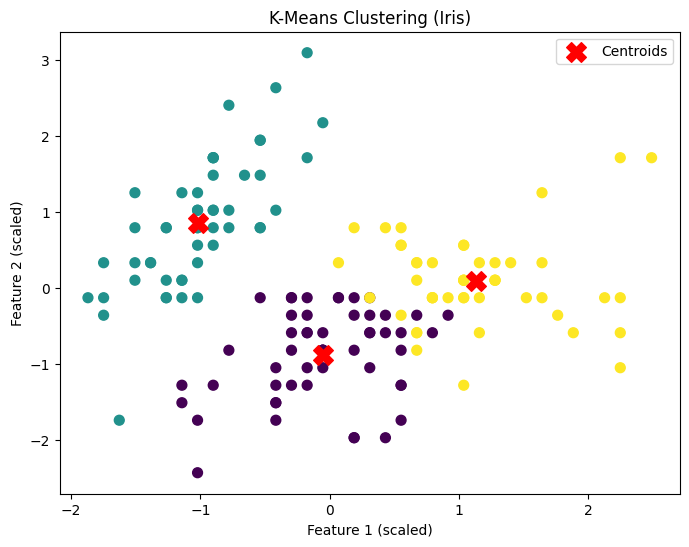

In [ ]:
#Program 4
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

iris = load_iris(as_frame=True)
X = iris.data # we will ignore labels
print("Dataset shape:", X.shape)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

X_clustered = X.copy()
X_clustered['Cluster'] = clusters
print("\nSample clustered data:\n", X_clustered.head())

plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters, cmap='viridis', s=50)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_ [:,1], c='red', marker='X', s=200, label="Centroids")
plt.title("K-Means Clustering (Iris)")
plt.xlabel("Feature 1 (scaled)")
plt.ylabel("Feature 2 (scaled)")
plt.legend()
plt.show()

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ----- Step 1: Load dataset -----
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

print("Dataset shape:", X.shape)

# ----- Step 2: Train-test split -----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# ----- Step 3: Bagging -----
bag_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bag_model.fit(X_train, y_train)
y_pred_bag = bag_model.predict(X_test)

print("\n=== Bagging Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_bag))
print(classification_report(y_test, y_pred_bag))

# ----- Step 4: Boosting (AdaBoost) -----
boost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    random_state=42
)

boost_model.fit(X_train, y_train)
y_pred_boost = boost_model.predict(X_test)

print("\n=== Boosting Results (AdaBoost) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_boost))
print(classification_report(y_test, y_pred_boost))

# ----- Step 5: Confusion Matrices -----
print("\nConfusion Matrix - Bagging:\n", confusion_matrix(y_test, y_pred_bag))
print("\nConfusion Matrix - Boosting:\n", confusion_matrix(y_test, y_pred_boost))

Dataset shape: (569, 30)

=== Bagging Results ===
Accuracy: 0.9415204678362573
              precision    recall  f1-score   support

           0       0.94      0.91      0.92        64
           1       0.94      0.96      0.95       107

    accuracy                           0.94       171
   macro avg       0.94      0.93      0.94       171
weighted avg       0.94      0.94      0.94       171


=== Boosting Results (AdaBoost) ===
Accuracy: 0.9590643274853801
              precision    recall  f1-score   support

           0       0.98      0.91      0.94        64
           1       0.95      0.99      0.97       107

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171


Confusion Matrix - Bagging:
 [[ 58   6]
 [  4 103]]

Confusion Matrix - Boosting:
 [[ 58   6]
 [  1 106]]
